# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** Ewurakua Amoah
**Student ID:** 74492028

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.

### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

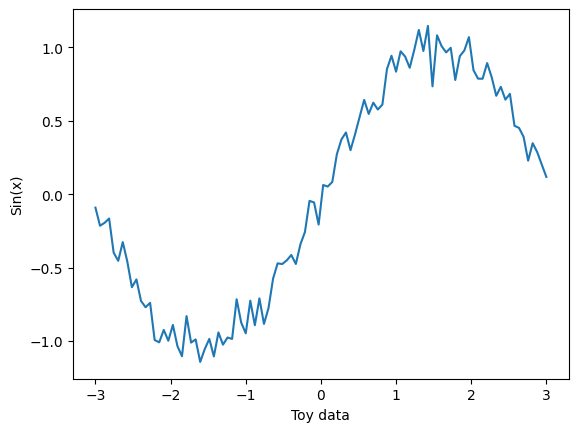

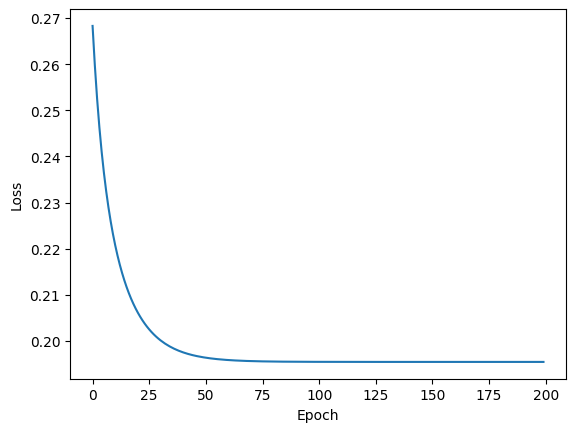

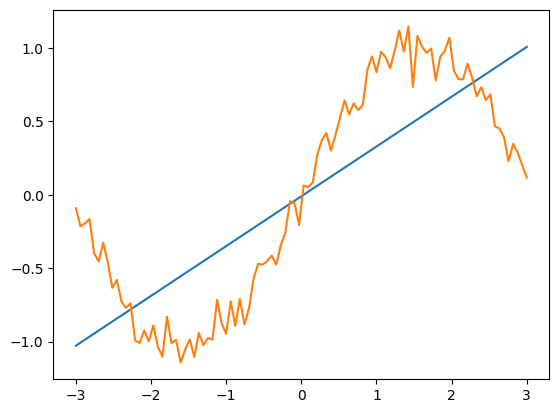

In [2]:
# TODO: Generate the toy data
#   x = np.linspace(-3, 3, 100); y = np.sin(x) + small Gaussian noise (std=0.1)
#   Plot it.
torch.manual_seed(RANDOM_STATE)
std=0.1
x = np.linspace(-3, 3, 100)

# TODO: Initialise w and b to small random values.
noise=np.random.normal(loc=0.0,scale=std, size=x.shape)
y = np.sin(x)+noise# add noise to sin graph
#plot data
plt.plot(x,y)
plt.ylabel("Sin(x)")
plt.xlabel("Toy data")
plt.show()

#assign weight and bias random small values
w=np.random.rand()
b=np.random.rand()
lr=0.02
# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
#   y_hat = w * x + b
#   loss  = np.mean((y_hat - y) ** 2)               # MSE
#   dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
#   db    = np.mean(2 * (y_hat - y))                # dLoss/db
#   w    -= lr * dw
#   b    -= lr * db
#   Record the loss at every step.

y_hat = w * x + b
loss  = np.mean((y_hat - y) ** 2) 
dw    = np.mean(2 * (y_hat - y) * x)
db    = np.mean(2 * (y_hat - y))

w    -= lr * dw
b    -= lr * db
losslist=[loss]
xval=range(200)

for i in range(199):#iterate over 199 times
    y_hat = w * x + b
    loss  = np.mean((y_hat - y) ** 2) 
    losslist.append(loss)
    dw    = np.mean(2 * (y_hat - y) * x)
    db    = np.mean(2 * (y_hat - y))
    w    -= lr * dw
    b    -= lr * db

#plot the loss curce over 200 steps
plt.plot(xval,losslist)
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()
# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.
#data with a fitted line over it
plt.plot(x,y_hat)
plt.plot(x,y)
plt.show()

**Student Reasoning — The single neuron**
*1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match
the code?*
*2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting,
and WHY can a single neuron never fit a sine wave, no matter how long you train?*

> **Answer:** [Double-click to edit]
1. -
Using the chain rule
$$
\frac{\partial loss}{\partial w}= \frac{\partial loss}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial w}
$$

$$
loss= \frac{(\hat{y}-y)^2}{n}
\\

\frac{\partial loss}{\partial \hat{y}} =2((\hat{y}-y))
$$

$$
\hat{y}=wx+b
\\
\frac{\partial \hat{y}}{\partial w}= x
$$

$$
\frac{\partial loss}{\partial w}=2((\hat{y}-y)) \cdot x

$$
for an arbitrary value of n

for all values of n it would be 
$$
\frac{\partial loss}{\partial w}= \frac{1}{n} \cdot \sum^n_{i=0} 2((\hat{y}-y)) \cdot x
$$

2. It is underfitting. It would not be able to as it always returns a linear function which would not be able to bent to a non linear function like the sine function

### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

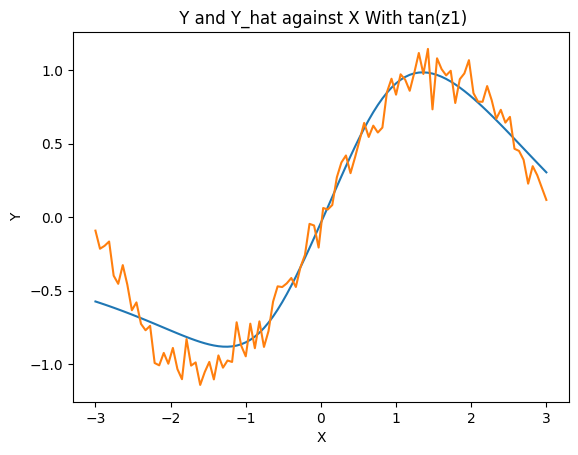

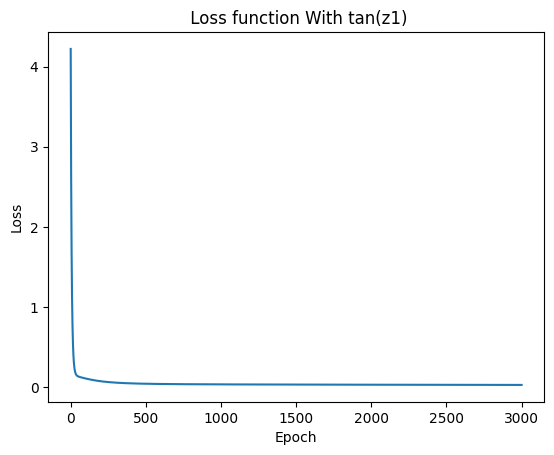

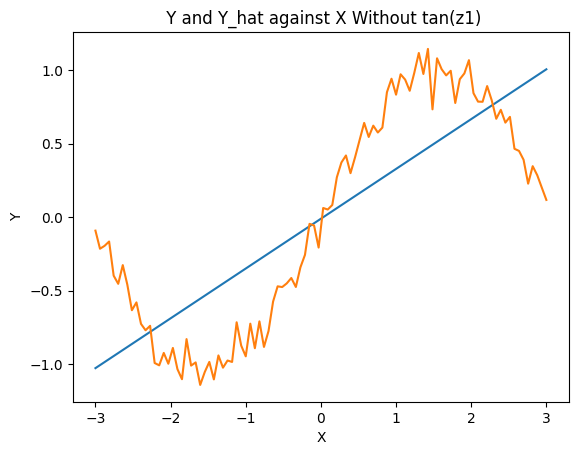

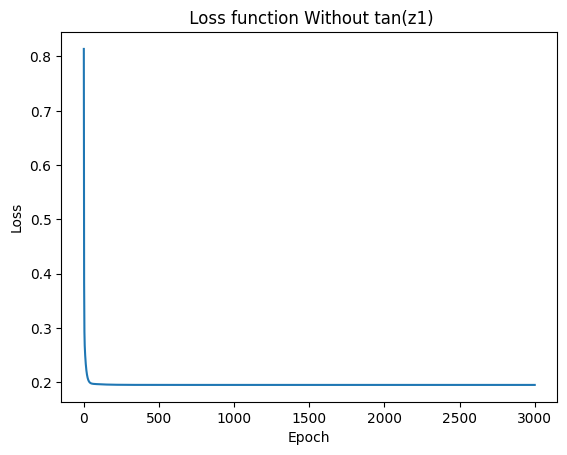

In [ ]:
torch.manual_seed(RANDOM_STATE)
# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
#   Small random values (e.g. np.random.randn(...) * 0.5)
#reshaping x and y values in order to be able to do calculations
x1=x.reshape(100,1)
y1=y.reshape(100,1)

# assign small random variables to the weights and biases
W1= np.random.randn(1,8) * 0.5
W2= np.random.randn(8, 1)* 0.5
b1= np.random.randn(8,)* 0.5
b2= np.random.randn(1,)* 0.5
# TODO: Forward pass (keep the intermediate values — you need them for backprop):
#   z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
#   h  = np.tanh(z1)        # activation
#   y_hat = h @ W2 + b2     # output, shape (100, 1)
#   loss  = np.mean((y_hat - y) ** 2)
z1 = x1 @ W1 + b1
h  = np.tanh(z1)
y_hat = h @ W2 + b2 
loss  = np.mean((y_hat - y1) ** 2)
losslist=[loss]
# TODO: Backward pass (the chain rule, layer by layer):
#   d_yhat = 2 * (y_hat - y) / len(y)
#   dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
#   dh  = d_yhat @ W2.T
#   dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
#   dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)
d_yhat = 2 * (y_hat - y1) / len(y1)
dW2 = h.T @ d_yhat 
db2 = d_yhat.sum(axis=0)
dh  = d_yhat @ W2.T

dz1 = dh * (1 - np.tanh(z1) ** 2)
dW1 = x.T @ dz1 
db1 = dz1.sum(axis=0) 

#update the weights
W1=W1-(lr * dW1)
W2=W2-(lr * dW2)



# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.
for i in range(3000):#iterate for 3000 times
  # Front propagation
  z1 = x1 @ W1 + b1 
  h  = np.tanh(z1)
  y_hat = h @ W2 + b2
  loss  = np.mean((y_hat - y1) ** 2)
  losslist.append(loss)

  #Back propagation
  d_yhat = 2 * (y_hat - y1) / len(y1)
  dW2 = h.T @ d_yhat 
  db2 = d_yhat.sum(axis=0)
  dh  = d_yhat @ W2.T
  dz1 = dh * (1 - np.tanh(z1) ** 2)
  dW1 = x.T @ dz1 
  db1 = dz1.sum(axis=0) 

  #update the weights
  W1=W1-(lr * dW1)
  W2=W2-(lr * dW2)

# TODO: Plot the loss curve AND the final fit over the data.
plt.plot(x1, y_hat)
plt.plot(x1,y1)
plt.xlabel("X")
plt.ylabel("Y")
plt.title(" Y and Y_hat against X With tan(z1)")
plt.show()
plt.plot(range(3001), losslist)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(" Loss function With tan(z1)")
plt.show()


#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
#Initializing the weights and biases
W1= np.random.randn(1,8) * 0.5
W2= np.random.randn(8, 1)* 0.5
b1= np.random.randn(8,)* 0.5
b2= np.random.randn(1,)* 0.5

#calculating layer 1 linear function
z1 = x1 @ W1 + b1
h  = z1# activation function
y_hat = h @ W2 + b2 # pass nonlinear node to output linear layer
loss  = np.mean((y_hat - y1) ** 2) # calculate loss
losslist=[loss] # initialize loss list
# TODO: Backward pass (the chain rule, layer by layer):
#   d_yhat = 2 * (y_hat - y) / len(y)
#   dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
#   dh  = d_yhat @ W2.T
#   dz1 = dh * (1 - z1 ** 2)     # derivative of tanh
#   dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)
d_yhat = 2 * (y_hat - y1) / len(y1)
dW2 = h.T @ d_yhat 
db2 = d_yhat.sum(axis=0)
dh  = d_yhat @ W2.T

dz1 = dh * (1 - np.tanh(z1) ** 2)
dW1 = x.T @ dz1 
db1 = dz1.sum(axis=0) 

#update the weights
W1=W1-(lr * dW1)
W2=W2-(lr * dW2)

for i in range(3000):#iterate for 3000 times
  # Front propagation
  z1 = x1 @ W1 + b1 
  h  = z1
  y_hat = h @ W2 + b2
  loss  = np.mean((y_hat - y1) ** 2)
  losslist.append(loss)

  #Back propagation
  d_yhat = 2 * (y_hat - y1) / len(y1)
  dW2 = h.T @ d_yhat 
  db2 = d_yhat.sum(axis=0)
  dh  = d_yhat @ W2.T
  dz1 = dh * (1 - np.tanh(z1) ** 2)
  dW1 = x.T @ dz1 
  db1 = dz1.sum(axis=0) 

  #update the weights
  W1=W1-(lr * dW1)
  W2=W2-(lr * dW2)

# TODO: Plot the loss curve AND the final fit over the data.
plt.plot(x1, y_hat)
plt.plot(x1,y1)
plt.xlabel("X")
plt.ylabel("Y")
plt.title(" Y and Y_hat against X Without tan(z1)")
plt.show()
plt.plot(range(3001), losslist)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(" Loss function Without tan(z1)")
plt.show()


**Student Reasoning — Depth and activations**
*1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1.
Explain mathematically why a stack of linear layers collapses into one linear layer.*
*2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few
columns of `h` against `x`.)*
*3. This is exactly what `loss.backward()` will automate in Section 2. In one sentence, what
is backpropagation?*

> **Answer:** [Double-click to edit]
1. 
$$
z1 = W \cdot x + b
$$

$$
h= tan(z1) 
\\
\implies h= tan(W \cdot x + b)
$$
which is not a linear function, so when this is placed in y hat you get:
$$
\hat{y}= h \cdot x + b
\\
\hat{y}=tan(W \cdot x + b) \cdot x + b 
$$

Whis is a nonlinear function
However
without the h
$$
z1 = W \cdot x + b
$$
Which is a linear function
$$
\hat{y}= z1 \cdot x + b
\\
\implies \hat{y}=(W \cdot x + b) \cdot x + b 
$$

Which also results in a linear funcion.


So each layer would be a result of a sum of linear equations which would lead to a bigger linear equation.

2.

1. Backpropagation is the process of moving backwards from the output whilst readjusting your weights based on the loss function.

### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

/Users/loisamoah/Library/CloudStorage/OneDrive-Personal/Desktop/2nd year/2nd sem/intro to AI/lab3/.venv/lib/python3.9/site-packages/numpy/core/_methods.py:118: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/var/folders/qt/kg_p7td53_555jl24h_svs_r0000gn/T/ipykernel_20680/353404038.py:16: RuntimeWarning: overflow encountered in square
  loss  = np.mean((y_hat - y1) ** 2)
/var/folders/qt/kg_p7td53_555jl24h_svs_r0000gn/T/ipykernel_20680/353404038.py:23: RuntimeWarning: overflow encountered in matmul
  dh  = d_yhat @ W2.T
/var/folders/qt/kg_p7td53_555jl24h_svs_r0000gn/T/ipykernel_20680/353404038.py:24: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)


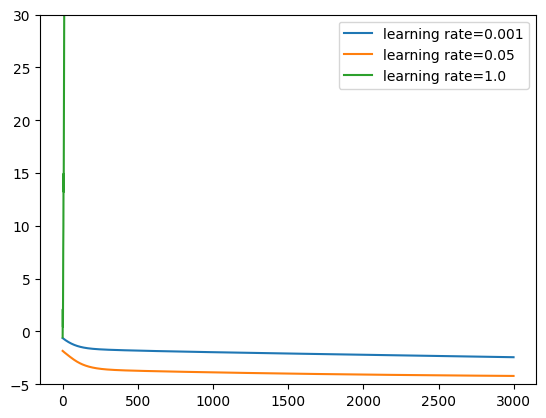

In [4]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.
torch.manual_seed(RANDOM_STATE)
def train_toy(lr, steps=3000, W1=W1, W2=W2, b1=b1, b2=b2):
    x1=x.reshape(100,1)
    y1=y.reshape(100,1)
    W1= np.random.randn(1,8) * 0.5
    W2= np.random.randn(8, 1)* 0.5
    b1= np.random.randn(8,)* 0.5
    b2= np.random.randn(1,)* 0.5
    losslist=[]
    for i in range(steps):
        z1 = x1 @ W1 + b1 
        h  = np.tanh(z1)
        y_hat = h @ W2 + b2
        loss  = np.mean((y_hat - y1) ** 2)
        losslist.append(loss)
    
        #Back propagation
        d_yhat = 2 * (y_hat - y1) / len(y1)
        dW2 = h.T @ d_yhat 
        db2 = d_yhat.sum(axis=0)
        dh  = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)
        dW1 = x.T @ dz1 
        db1 = dz1.sum(axis=0) 
    
        #update the weights
        W1=W1-(lr * dW1)
        W2=W2-(lr * dW2)
    return losslist

# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).
losslist1=train_toy(0.001)
losslist2=train_toy(0.05)
losslist3=train_toy(1)

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.
plt.plot(range(3000), np.log(losslist1), label="learning rate=0.001")
plt.plot(range(3000), np.log(losslist2), label="learning rate=0.05")
plt.plot(range(3000), np.log(losslist3), label="learning rate=1.0")
plt.ylim(-5,30)
plt.legend()
plt.show()

**Student Reasoning — Learning rate**
*Describe what each of the three curves shows. Why does a too-large learning rate make the
loss explode or oscillate instead of just "learning faster"?*

> **Answer:** [Double-click to edit]
> The first two (0.001 and 0.05)have a reasonable elbow curve, but when the learning rate increases to 1 the line goes on an upwards climb which is an explosion meaning the losses just increase on iteration instead of redusing and gradually becoming close to 0
>  A learning rate determines how far the weight moves on an iteration. A arge learning rate causes a weight to change too much making it either jump back and forth over the optimal weight (oscillation) or move quickly away from the optimal rate (exploding) 


---
# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.

### Part 2.1 — Preprocess and split (recycled from Lab 2)
Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.

In [5]:
# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).
torch.manual_seed(RANDOM_STATE)
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns
import torch
from torch.utils.data import TensorDataset, DataLoader
scaler = StandardScaler()
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
obesity= pd.read_csv(OBESITY_URL)
obesity.columns = obesity.columns.str.strip()
# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
##   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.

obesity['family_history_with_overweight_e'] = obesity['family_history_with_overweight'].map({'yes': 1, 'no': 0})
obesity['FAVC_e'] = obesity['FAVC'].map({'yes': 1, 'no': 0})
obesity['SMOKE_e'] = obesity['SMOKE'].map({'yes': 1, 'no': 0})
obesity['SCC_e'] = obesity['SCC'].map({'yes': 1, 'no': 0})

encoder = LabelEncoder()
obesity['CAEC_e']=encoder.fit_transform(obesity[['CAEC']]) # type: ignore
obesity['CALC_e']=encoder.fit_transform(obesity[['CALC']]) # type: ignore

categories=['Gender','MTRANS']
obesity=pd.get_dummies(data=obesity,columns=categories,drop_first=False, dtype=int)

obesity['NObeyesdad_e']=encoder.fit_transform(obesity[['NObeyesdad']]) # type: ignore
num_columns=[ 'Age', 'Height', 'Weight', 'FCVC','NCP','FAF','CH2O','TUE']
# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).
x3=obesity.drop(columns=['NObeyesdad','NObeyesdad_e','family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC','CAEC', 'CALC'])
y3=obesity['NObeyesdad_e']

X_test, X_temp, y_test, y_temp = train_test_split(#creates a validation and a test
    x3, y3, test_size=0.4, random_state=RANDOM_STATE, stratify=y3
)
X_train, X_val, y_train, y_val = train_test_split(# creates a train set
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp
)
X_train_scaled=X_train
X_test_scaled=X_test
X_val_scaled=X_val




# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests — 
#    remember Section 1, where all gradients depended on x!)
X_train_scaled[num_columns] = scaler.fit_transform(X_train[num_columns])
X_test_scaled[num_columns] = scaler.transform(X_test[num_columns])
X_val_scaled[num_columns] = scaler.transform(X_val[num_columns])
x_kmeans=X_train_scaled
# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader
X_train_scaled=torch.tensor(X_train_scaled.to_numpy(),dtype=torch.float32)# .values extracts the internal list from the data frame
X_test_scaled=torch.tensor(X_test_scaled.to_numpy(),dtype=torch.float32)
X_val_scaled=torch.tensor(X_val_scaled.to_numpy(),dtype=torch.float32)

y_train=torch.tensor(y_train.to_numpy(),dtype=torch.long)
y_test=torch.tensor(y_test.to_numpy(),dtype=torch.long)
y_val=torch.tensor(y_val.to_numpy(),dtype=torch.long)

#create a tensor dataset for each set
train_dataset=TensorDataset(X_train_scaled,y_train)
val_dataset=TensorDataset(X_val_scaled,y_val)
test_dataset=TensorDataset(X_test_scaled,y_test)

#wrap to dataset
train_loader= DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader= DataLoader(val_dataset, batch_size=32, shuffle=True)
test_loader= DataLoader(test_dataset, batch_size=32, shuffle=True)

/Users/loisamoah/Library/CloudStorage/OneDrive-Personal/Desktop/2nd year/2nd sem/intro to AI/lab3/.venv/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/loisamoah/Library/CloudStorage/OneDrive-Personal/Desktop/2nd year/2nd sem/intro to AI/lab3/.venv/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/loisamoah/Library/CloudStorage/OneDrive-Personal/Desktop/2nd year/2nd sem/intro to AI/lab3/.venv/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (

**Student Reasoning — Preprocessing for neural networks**
*1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in
PyTorch?*
*2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care
so much? Connect your answer to the gradient formulas you wrote in Section 1.*
*3. What does `shuffle=True` on the training DataLoader do, and why does it help?*

> **Answer:** [Double-click to edit]
>
> 3. "shuffle= true" shuffles the dataset at each epoch which reduces overfitting

### Part 2.2 — Design the network
An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [12]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)

torch.manual_seed(RANDOM_STATE)
class FeedForwardNet(nn.Module):
    def __init__(self, input_dim=7, hidden_sizes=(64, 32, 24), n_classes=7):
        super().__init__()
        # ensures thta they are fully connected
        self.fc1=nn.Linear(input_dim, hidden_sizes[0])#layer 1
        self.fc2=nn.Linear(hidden_sizes[0], hidden_sizes[1])#layer 2
        self.fc3=nn.Linear(hidden_sizes[1], hidden_sizes[2])
        self.out=nn.Linear(hidden_sizes[2], n_classes)#output layer

    def forward(self, x):#to move each layer forward
        x=F.relu(self.fc1(x))#x passes through layer one and applies the relu fulction
        x = F.relu(self.fc2(x))#output from layer 1 passes through layer 2 and applies the relu fulction
        x=F.relu(self.fc3(x))#output layer
        x=self.out(x)
        return x

class FeedForwardNetPt2(nn.Module):
    def __init__(self, input_dim=7, hidden_sizes=(64, 32, 24), n_classes=7, dropout=0.0):
        super().__init__()
        # ensures that they are fully connected
        self.in_dim=input_dim
        self.hidden_sizes=hidden_sizes
        self.layer=nn.ModuleDict()
        self.dropout=nn.Dropout(dropout)

        for i in range(len(hidden_sizes)):
            self.layer[f"fc{i+1}"]=nn.Linear(self.in_dim, hidden_sizes[i])
            self.in_dim=hidden_sizes[i]
        
        self.out=nn.Linear(self.in_dim, n_classes)#output layer

    def forward(self, x):#to move each layer forward
        for i in range(len(self.hidden_sizes)):
            x=F.relu(self.layer[f"fc{i+1}"](x))#x passes through layer one and applies the relu fulction
            x=self.dropout(x)
        
        x=self.out(x)
        return x


    

# TODO: Instantiate, move to DEVICE, print the model.
model= FeedForwardNet(X_train_scaled.shape[1])# returns number of features of train dataset as size
model=model.to(DEVICE)
print(model)
# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.
trainableparam=sum(p.numel() for p in model.parameters() if p.requires_grad)
print(trainableparam)

FeedForwardNet(
  (fc1): Linear(in_features=21, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=24, bias=True)
  (out): Linear(in_features=24, out_features=7, bias=True)
)
4455


**Student Reasoning — Architecture**
*1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.*
*2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.*
*3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)*

> **Answer:** [Double-click to edit]
> 1
> 
$$
Layer1 \implies (21 \cdot 64) +64 = 1408
$$

$$
Layer2 \implies (64 \cdot 32)+ 32 = 2080
$$

$$
Layer3 \implies (32 \cdot 24)+ 24 = 792
$$

$$
Output \implies (24 \cdot 7) + 7= 175
$$

$$
1408+2080+792+175= 4455
$$

>2. They are simple and fast
> 3. It would produce a linear function

### Part 2.3 — The training loop
The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

Epoch: 1 Training Accuraccy: 0.14218009478672985 Training Loss: 1.9430647523482263  Validation Accuracy:  0.15130023640661938  Validation Loss: 1.9292122342625972
Epoch: 2 Training Accuraccy: 0.26303317535545023 Training Loss: 1.9124243152085074  Validation Accuracy:  0.3664302600472813  Validation Loss: 1.8981888421038364
Epoch: 3 Training Accuraccy: 0.4028436018957346 Training Loss: 1.8672028881678648  Validation Accuracy:  0.4231678486997636  Validation Loss: 1.8441127609135692
Epoch: 4 Training Accuraccy: 0.46919431279620855 Training Loss: 1.793163839109701  Validation Accuracy:  0.3829787234042553  Validation Loss: 1.746110539627977
Epoch: 5 Training Accuraccy: 0.4218009478672986 Training Loss: 1.6651691831118687  Validation Accuracy:  0.38534278959810875  Validation Loss: 1.6040308579767286
Epoch: 6 Training Accuraccy: 0.4099526066350711 Training Loss: 1.495163740704975  Validation Accuracy:  0.41134751773049644  Validation Loss: 1.4334766191230035
Epoch: 7 Training Accuraccy: 0.

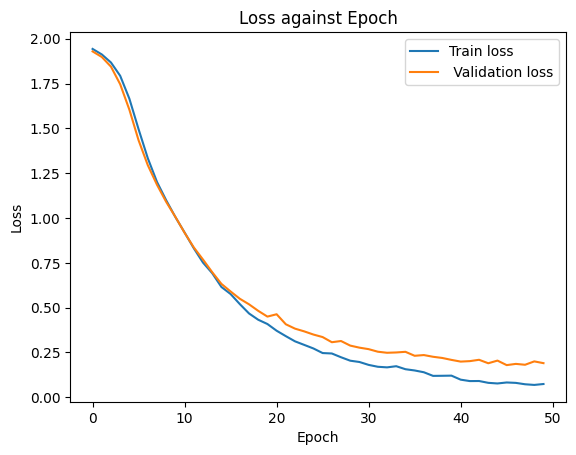

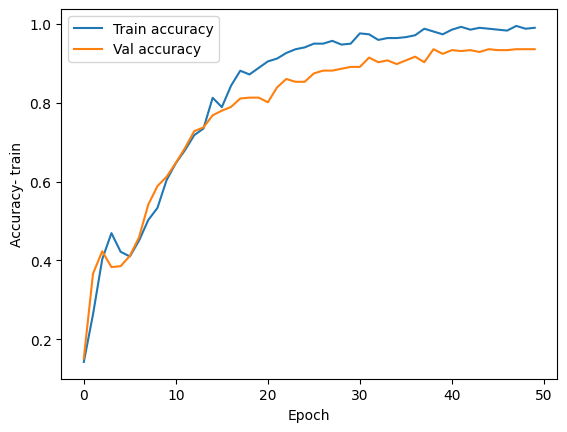

In [13]:
# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify
torch.manual_seed(RANDOM_STATE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3) 
torch.manual_seed(RANDOM_STATE)
# TODO: Train for at least 50 epochs. Each epoch:
#   1. model.train(); for xb, yb in train_loader:
#        optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
#        loss = criterion(logits, yb.to(DEVICE))
#        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
#        optimizer.step()         # <- the update rule you wrote in Part 1.1
#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
#   3. Append everything to history lists; print a one-line summary per epoch.
best_val_accuracy=0
from time import time
start = time()

epoch=50
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for i in range(epoch):
    model.train()
    running_loss, correct, total = 0, 0, 0
    
    for xb, yb in train_loader:#for each pass
        optimizer.zero_grad()
        #assign to DEVICE
        xb=xb.to(DEVICE)
        yb=yb.to(DEVICE)

        logits = model.forward(xb)#forward pass
        loss = criterion(logits, yb)# calculate loss
        
        loss.backward() #backwards step
        optimizer.step()# update gradienr
        running_loss += loss.item() * xb.size(0) # calculate losses
        preds = logits.argmax(1)
        correct += (preds == yb).sum().item() # count number of correct predictions
        total += yb.size(0)
    #calculate avg train loss and accuracy per epoch 
    avg_loss = running_loss / total
    train_acc = correct / total

    #append train loss and accuracy
    history["train_loss"].append(avg_loss)
    history["train_acc"].append(train_acc)

    model.eval()
    with torch.no_grad():
        running_loss_val, correct_val, total_val = 0.0, 0, 0   
        for xb, yb in val_loader: #for each pass
            #assign to DEVICE
            xb=xb.to(DEVICE)
            yb=yb.to(DEVICE)
            logits = model.forward(xb)#forward pass
            loss = criterion(logits, yb)# calculate loss
            running_loss_val += loss.item() * xb.size(0) # running loss
            preds = logits.argmax(1) # get the models prediction
            correct_val += (preds == yb).sum().item() # count when aswer is correcr
            total_val += yb.size(0) #increment number of sizes

    #calculate avg loss and accuracy per epoch for the validation set
    val_loss = running_loss_val / total_val
    val_acc = correct_val / total_val
    #preds_val = torch.cat(all_preds).numpy()
    #yb = torch.cat(all_labels).numpy()  
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch: {i+1} Training Accuraccy: {train_acc} Training Loss: {avg_loss}  Validation Accuracy:  {val_acc}  Validation Loss: {val_loss}")
    # TODO: Save the best model (highest validation accuracy):
    #   torch.save(model.state_dict(), "ffn_best.pt")
    # save best accuracy 
    if val_acc> best_val_accuracy:
        best_val_accuracy=val_acc
        torch.save(model.state_dict(), "ffn_best.pt")
    
#calculate training time
timetaken=(time()-start)


# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.
plt.plot(range(epoch),history["train_loss"], label="Train loss")
plt.plot(range(epoch),history["val_loss"], label=" Validation loss")
plt.legend()
plt.title("Loss against Epoch")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()


plt.plot(range(epoch),history["train_acc"], label= "Train accuracy")
plt.plot(range(epoch),history["val_acc"], label="Val accuracy")
plt.legend()
plt.ylabel("Accuracy- train")
plt.xlabel("Epoch")
plt.show()



**Student Reasoning — Training**
*1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is
the forward pass, which computes gradients, which is the update rule?*
*2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the
specific numbers that back up your claim.*
*3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?*

> **Answer:** [Double-click to edit]
> forward pass, Numpy
>  z1 = x1 @ W1 + b1
> h  = z1# activation function
> y_hat = h @ W2 + b2
>forward pass, Pytorch
> logits = model.forward(xb)
 loss = criterion(logits, yb)
>
> Compute gradient
> loss.backward()
>
> Update rule;
> optimizer.step()
>
> 2. It is overfitted fitted, the model did better on the validation set than the training set around epoch 15 up till 50, Epoch 50: Training accuracy: 0.990521327014218  Validation Accuracy:  0.9361702127659575
> Epoch: 14 Training Accuraccy: 0.7345971563981043 Validation Accuracy:  0.7375886524822695  
> Epoch: 15 Training Accuraccy: 0.8127962085308057 Validation Accuracy:  0.7683215130023641
>
> 3. It resets the gradients and keeps the old gradients from earlier sets with being mixed with the new, reducing inaccuracy in calculations that may be brought about with pre existing gradients.

### Part 2.4 — Experiments: how training choices change the outcome
Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.

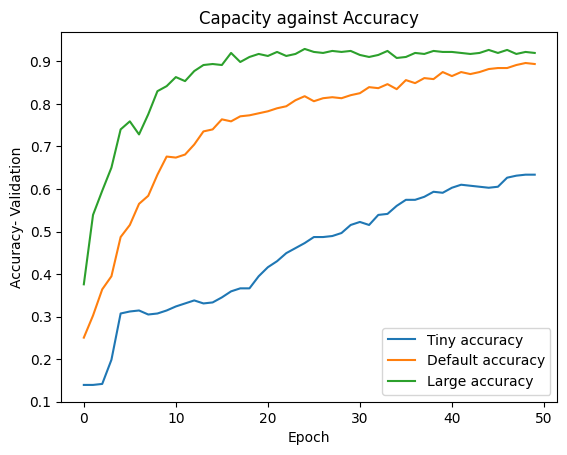

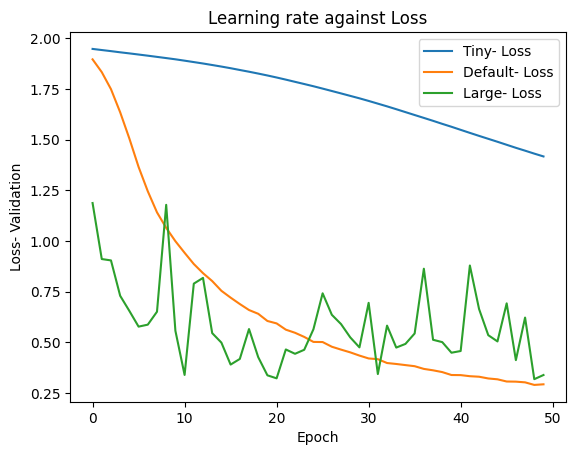

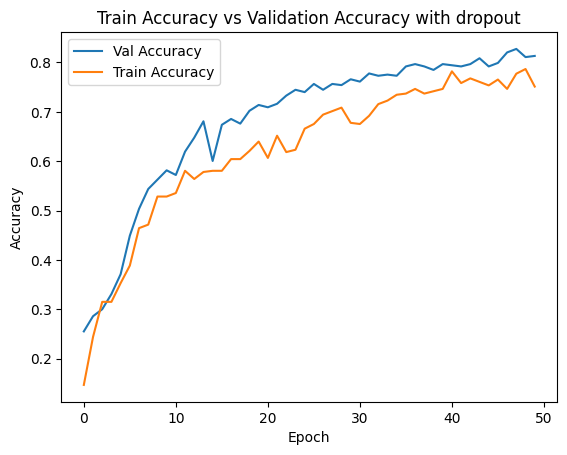

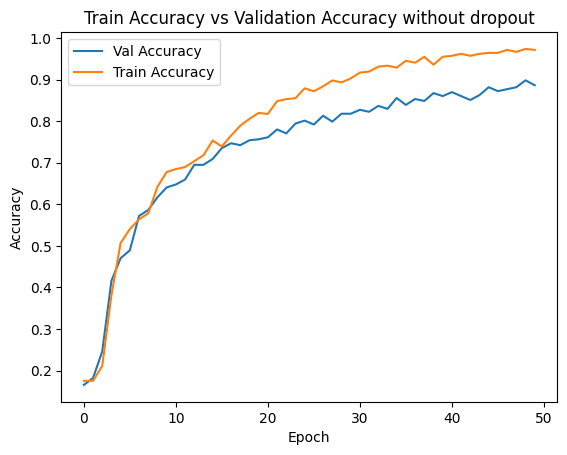

In [14]:
# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...
def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
    train_loader= DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader= DataLoader(val_dataset, batch_size=batch_size, shuffle=True)

    model= FeedForwardNetPt2(X_train_scaled.shape[1],hidden_sizes=hidden_sizes,dropout=dropout)# returns number of features of train dataset as size
    model=model.to(DEVICE)
    torch.manual_seed(RANDOM_STATE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr) 

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    for i in range(epochs):
        model.train()
        running_loss_train, correct, total = 0, 0, 0
        
        for xb, yb in train_loader:
            optimizer.zero_grad()
            xb=xb.to(DEVICE)
            yb=yb.to(DEVICE)
            logits = model.forward(xb)
            loss = criterion(logits, yb)
            loss.backward() 
            optimizer.step()

            running_loss_train += loss.item() * xb.size(0)
            preds = logits.argmax(1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

        train_loss = running_loss_train / total
        train_acc = correct / total
        
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        model.eval()
        with torch.no_grad():
            running_loss_val, correct_val, total_val = 0.0, 0, 0   
            for xb, yb in val_loader:
                xb=xb.to(DEVICE)
                yb=yb.to(DEVICE)
                logits = model.forward(xb)
                loss = criterion(logits, yb)
                
                running_loss_val += loss.item() * xb.size(0)
                preds = logits.argmax(1)
                correct_val += (preds == yb).sum().item()
                total_val += yb.size(0)

        val_loss = running_loss_val / total_val
        val_acc = correct_val / total_val 
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
    return history
# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.
tiny=run_experiment(hidden_sizes=(8,) )
default=run_experiment(hidden_sizes=(64,32) )
large=run_experiment(hidden_sizes=(256, 128, 64))

plt.plot(range(epoch),tiny["val_acc"], label= "Tiny accuracy")
plt.plot(range(epoch),default["val_acc"], label="Default accuracy")
plt.plot(range(epoch),large["val_acc"], label="Large accuracy")
plt.legend()
plt.title("Capacity against Accuracy")
plt.ylabel("Accuracy- Validation")
plt.xlabel("Epoch")
plt.show()

# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.
tiny=run_experiment(lr=1e-4)
default=run_experiment(lr=1e-3)
large=run_experiment(lr=1e-1)
plt.plot(range(epoch),tiny["val_loss"], label= "Tiny- Loss")
plt.plot(range(epoch),default["val_loss"], label="Default- Loss")
plt.plot(range(epoch),large["val_loss"], label="Large- Loss")
plt.legend()
plt.title("Learning rate against Loss")
plt.ylabel("Loss- Validation")
plt.xlabel("Epoch")
plt.show()
# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.
dropout=run_experiment(dropout=0.3)
standard=run_experiment()
plt.plot(range(epoch),dropout["val_acc"], label="Val Accuracy")
plt.plot(range(epoch),dropout["train_acc"], label="Train Accuracy")
plt.legend()
plt.title("Train Accuracy vs Validation Accuracy with dropout")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.show()

plt.plot(range(epoch),standard["val_acc"], label="Val Accuracy")
plt.plot(range(epoch),standard["train_acc"], label="Train Accuracy")
plt.legend()
plt.title("Train Accuracy vs Validation Accuracy without dropout")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.show()

**Student Reasoning — Experiments**
*1. Capacity: did the largest network win on validation data? Where do you see diminishing
returns or overfitting?*
*2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?*
*3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two
sentences HOW dropout achieves this.*

> **Answer:** [Double-click to edit]
> 1.The Largest network won
>
> 2. I saw the same issue appear as it did on Part 1.3
>
> 3. the train-vs-validation gap was reduced by the dropout. How this happens is that it randomly switches off a fraction of the neurons of each layer, forcing the layer to move from co-adaptive tendencies into regularization. The layer has to work with a smaller set of neurons which are random making it discover newer features and prevents overfitting.

### Part 2.5 — Final evaluation and showdown with Lab 2
One honest number on the test set — then compare with your classical models.

Accuracy: 0.924 Macro: 0.921


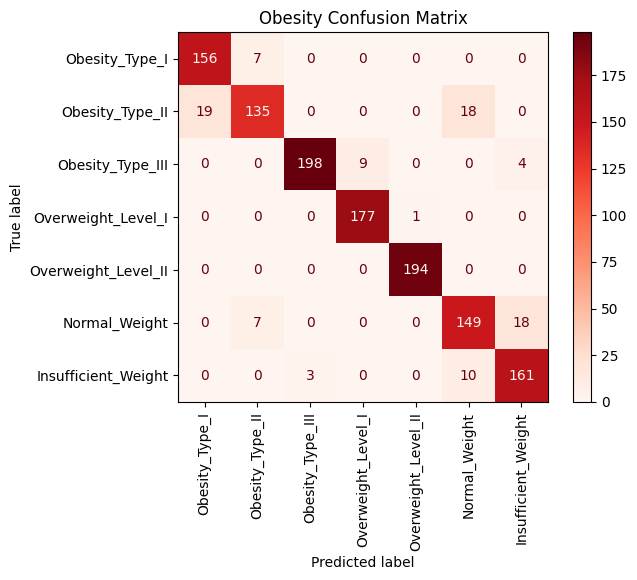

                           KNNeighbors Neural Network
cols                                                 
test accuracy                    0.942       0.924171
test macro-F1                    0.938       0.920898
training time                      0.7       2.250622
number of parameters/trees           5              -


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
# TODO: Load your best configuration's weights; model.eval().
model= FeedForwardNet(X_train_scaled.shape[1]) # initialize model
model.load_state_dict(torch.load("ffn_best.pt"))# load best weights
model.eval()

# TODO: Report test ACCURACY and MACRO-F1
#   from sklearn.metrics import accuracy_score, f1_score, classification_report
with torch.no_grad(): # keeps no gradients
    all_preds, all_labels = [], [] # initialize lists
    for xb, yb in test_loader: # for each set
            # assign to DEVICE
            xb=xb.to(DEVICE)
            yb=yb.to(DEVICE)
            logits = model.forward(xb)# forward pass
            loss = criterion(logits, yb)#calculate loss
            
            preds = logits.argmax(1) # get y_hat
            all_preds.append(preds.cpu()) # get all predictions
            all_labels.append(yb.cpu()) # get all labels
preds = torch.cat(all_preds).numpy() # convert to torch
yb = torch.cat(all_labels).numpy()   
test_acc=accuracy_score(yb,preds) # calculate test accuracy
test_macro=f1_score(yb,preds,average='macro') # get macro value
print(f"Accuracy: {round(test_acc,3)} Macro: {round(test_macro,3)}") # output
        
    
    
# TODO: Confusion matrix for the test set with the 7 class names
#   from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(yb, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Obesity_Type_I','Obesity_Type_II', 'Obesity_Type_III','Overweight_Level_I','Overweight_Level_II','Normal_Weight','Insufficient_Weight' ])
disp.plot(cmap='Reds',xticks_rotation=90,)
plt.title('Obesity Confusion Matrix')
plt.show()
# TODO: Build a small comparison table (a pandas DataFrame is fine):
#   rows = [your best Lab 2 classifier, this neural network]
#   cols = [test accuracy, test macro-F1, training time, number of parameters/trees]
data={
      'cols': ["test accuracy", "test macro-F1", "training time", "number of parameters/trees"],
      "KNNeighbors": [ "0.942", "0.938","0.7" ,"5"],
      "Neural Network": [test_acc, test_macro, timetaken, "-"]
} # get data to be placed in dataframe
compare=pd.DataFrame(data=data) # place data in dataframe
compare.set_index("cols", inplace=True)
print(compare)

**Student Reasoning — Final evaluation**
*1. Which obesity levels does the network still confuse, and are they the same ones your
Lab 2 classifier confused?*
*2. Who wins the showdown — the neural network or the classical model? Was the extra effort
of deep learning worth it on THIS dataset? When would it be?*

> **Answer:** [Double-click to edit]
> 1. It confuses Obesity Type I and Obesity Type II, Normal Weight and Obesity Type II and Normal Weight with Insufficient weight. The lab 2 classifier confused Normal Weight and Obesity Type II as well and also Obesity Type I and Type II, It has the same confusion but woth lower values.
>
> 2. The classical model wins, it is more accurate  and is faster to train. In this case it was not, as the classical models were quicker and better. It would be better with unstructured more complex data where it can handle these kinds without preprocessing.

---
# Section 3 — Reflection

*Answer in a few sentences each:*

1. **The black box, opened:** Name the three most important things happening inside
   `loss.backward()` and `optimizer.step()`, in your own words.
2. **Hyperparameters:** If you could tune only ONE hyperparameter on a new problem, which
   would you pick and why?
3. **Overfitting:** Across your experiments, where did you see the biggest
   train-vs-validation gap, and which intervention reduced it most?
4. **Looking ahead:** This network treats every input feature independently. Next lab we move
   to images, where nearby pixels are related. Why might a plain MLP struggle with images,
   and what property should a better architecture have?

> **Answer:** [Double-click to edit]

---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
- [ ] Notebook committed and pushed to your `lab-3-feedforward-networks` repository, with
      incremental commits (not one final dump).
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository.